# BERTopic & LDA Analysis

Анализ результатов fuzzy-топик-моделирования:
- мягкое распределение `topic_membership` (документ -> темы),
- визуализация документов на scatter,
- дендрограмма близости тем,
- метрики когерентности,
- LDA.

In [ ]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from umap import UMAP

In [17]:
# Пути к артефактам пайплайна
DOC_TOPICS_PATH = Path('paper_output_preprocessed/paper_doc_topics.jsonl')
TOPIC_INFO_PATH = Path('paper_output_preprocessed/paper_topic_info.jsonl')
DOC_EMB_PATH = Path('paper_output_preprocessed/paper_doc_embeddings.npy')
DOC_EMB_REDUCED_PATH = Path('paper_output_preprocessed/paper_doc_embeddings_reduced.npy')
TERM_EMB_PATH = Path('paper_output_preprocessed/paper_term_embeddings.npz')

if not DOC_TOPICS_PATH.exists():
    raise FileNotFoundError(f'File not found: {DOC_TOPICS_PATH}')
if not TOPIC_INFO_PATH.exists():
    raise FileNotFoundError(f'File not found: {TOPIC_INFO_PATH}')

# Гиперпараметры ИМЕННО вашего запуска fuzzy_bertopic_paper_pipeline.py
SCRIPT_EMBEDDING_MODEL = 'deepvk/USER-bge-m3'
SCRIPT_NUM_TOPICS_REQUESTED = 10
SCRIPT_TOP_WORDS = 10
SCRIPT_RANK_COEFF = 'inverse'
SCRIPT_SEED = 42
SCRIPT_UMAP_NEIGHBORS = 15
SCRIPT_UMAP_COMPONENTS = 5
SCRIPT_UMAP_MIN_DIST = 0.0
SCRIPT_UMAP_METRIC = 'cosine'
SCRIPT_UMAP_INIT = 'random'
SCRIPT_FCM_M = 2.0
SCRIPT_FCM_MAX_ITER = 300
# В вашем CLI batch_size не передавался, поэтому используются дефолты скрипта.
SCRIPT_DOC_EMBEDDING_BATCH_SIZE = 2
SCRIPT_TERM_EMBEDDING_BATCH_SIZE = 2
SCRIPT_MIN_DF = 2
SCRIPT_MAX_VOCAB_SIZE = 20000
SCRIPT_ABSENT_SIMILARITY = -2.0

# Параметры анализа ноутбука
TOP_N_WORDS_FOR_COHERENCE = SCRIPT_TOP_WORDS
MIN_TOKEN_LEN = 3
RANDOM_STATE = SCRIPT_SEED

In [18]:
def load_jsonl(path: Path) -> list[dict]:
    rows: list[dict] = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            rows.append(json.loads(s))
    return rows


doc_rows = load_jsonl(DOC_TOPICS_PATH)
topic_rows = load_jsonl(TOPIC_INFO_PATH)

if not doc_rows:
    raise ValueError('paper_doc_topics.jsonl is empty')
if not topic_rows:
    raise ValueError('paper_topic_info.jsonl is empty')

df_docs = pd.DataFrame(doc_rows)
df_topics = pd.DataFrame(topic_rows)

membership = np.asarray(df_docs['topic_membership'].tolist(), dtype=float)
if membership.ndim != 2:
    raise ValueError('topic_membership must be a 2D matrix')

n_docs, n_topics = membership.shape
print(f'Documents: {n_docs}, topics: {n_topics}')
print(f'Topic info rows: {len(df_topics)}')

df_docs['dominant_topic_from_membership'] = membership.argmax(axis=1)
df_docs['dominant_prob'] = membership.max(axis=1)
df_docs['membership_entropy'] = -np.sum(np.where(membership > 0, membership * np.log(membership), 0.0), axis=1)

# Загружаем кэш эмбеддингов, если он сохранен пайплайном.
cached_doc_embeddings = None
cached_doc_embeddings_reduced = None
cached_term_embedding_by_term: dict[str, np.ndarray] = {}

if DOC_EMB_PATH.exists():
    arr = np.load(DOC_EMB_PATH)
    if arr.shape[0] == n_docs:
        cached_doc_embeddings = np.asarray(arr, dtype=float)

if DOC_EMB_REDUCED_PATH.exists():
    arr = np.load(DOC_EMB_REDUCED_PATH)
    if arr.shape[0] == n_docs:
        cached_doc_embeddings_reduced = np.asarray(arr, dtype=float)

if TERM_EMB_PATH.exists():
    npz = np.load(TERM_EMB_PATH, allow_pickle=True)
    terms = [str(t) for t in npz['terms'].tolist()]
    embs = np.asarray(npz['embeddings'], dtype=float)
    if len(terms) == embs.shape[0]:
        cached_term_embedding_by_term = {t: embs[i] for i, t in enumerate(terms)}

print('Cached doc embeddings loaded:', cached_doc_embeddings is not None)
print('Cached reduced doc embeddings loaded:', cached_doc_embeddings_reduced is not None)
print('Cached term embeddings loaded:', len(cached_term_embedding_by_term))

df_docs[['book_title', 'dominant_topic', 'dominant_topic_from_membership', 'dominant_prob', 'membership_entropy']].head()

Documents: 191, topics: 10
Topic info rows: 10
Cached doc embeddings loaded: True
Cached reduced doc embeddings loaded: True
Cached term embeddings loaded: 4561


,book_title,dominant_topic,dominant_topic_from_membership,dominant_prob,membership_entropy
0,Русская ловушка,7,7,0.328862,1.960029
1,Почему важна демография,2,2,0.830818,0.769186
2,Перманентная современность и динамика культуры,2,2,0.497655,1.625548
3,Урбанизация по-китайски,7,7,0.485290,1.704836
4,Имидж региона в стратегии развития территории,5,5,0.363860,1.829417


In [19]:
# Scatter (Plotly): документы в пространстве soft-membership
# Используем UMAP-гиперпараметры скрипта (neighbors/components/min_dist/metric/init/seed).
import plotly.express as px
import plotly.graph_objects as go


def _safe_umap_neighbors(requested_neighbors: int, n_docs_local: int) -> int:
    if n_docs_local <= 2:
        return 1
    return max(2, min(requested_neighbors, n_docs_local - 1))


n_neighbors = _safe_umap_neighbors(SCRIPT_UMAP_NEIGHBORS, n_docs)
if n_docs <= 2:
    n_components = 1
else:
    n_components = max(2, min(SCRIPT_UMAP_COMPONENTS, membership.shape[1], n_docs - 1))

umap_model = UMAP(
    n_components=n_components,
    n_neighbors=n_neighbors,
    min_dist=SCRIPT_UMAP_MIN_DIST,
    metric=SCRIPT_UMAP_METRIC,
    init=SCRIPT_UMAP_INIT,
    random_state=RANDOM_STATE,
)
coords_full = umap_model.fit_transform(membership)

# Для scatter берем первые 2 оси (если n_components=1, вторую ось заполняем нулями)
x = coords_full[:, 0]
y = coords_full[:, 1] if coords_full.shape[1] > 1 else np.zeros_like(x)

plot_df = pd.DataFrame({
    'x': x,
    'y': y,
    'dominant_topic': df_docs['dominant_topic_from_membership'].astype(int),
    'dominant_prob': df_docs['dominant_prob'].astype(float),
    'book_title': df_docs.get('book_title', pd.Series([''] * len(df_docs))).astype(str),
    'reviewer_id': df_docs.get('reviewer_id', pd.Series([''] * len(df_docs))).astype(str),
})

fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='dominant_topic',
    size='dominant_prob',
    size_max=30,
    hover_data={
        'book_title': True,
        'reviewer_id': True,
        'dominant_topic': True,
        'dominant_prob': ':.4f',
        'x': ':.4f',
        'y': ':.4f',
    },
    title='Documents in fuzzy topic-membership space (UMAP, script params)',
)
fig.update_traces(marker={'line': {'width': 0.4, 'color': 'black'}, 'opacity': 0.8})

# Одна подпись на кластер: 5 топ-слов темы в центре соответствующего кластера.
centers = (
    plot_df.groupby('dominant_topic', as_index=False)[['x', 'y']]
    .mean()
    .sort_values('dominant_topic')
)

topic_label_map = {}
for row in topic_rows:
    tid = int(row.get('topic_id'))
    words = list(row.get('top_words', []))[:5]
    topic_label_map[tid] = ', '.join(words) if words else f'topic_{tid}'

centers['cluster_label'] = centers['dominant_topic'].map(
    lambda t: topic_label_map.get(int(t), f'topic_{int(t)}')
)

fig.add_trace(
    go.Scatter(
        x=centers['x'],
        y=centers['y'],
        mode='text',
        text=centers['cluster_label'],
        textposition='middle center',
        textfont={'size': 10, 'color': 'black'},
        showlegend=False,
        hoverinfo='skip',
    )
)

fig.update_layout(
    xaxis_title='UMAP-1',
    yaxis_title='UMAP-2',
    legend_title='Dominant topic id',
    width=1000,
    height=500,
)
fig.show()

print(
    'UMAP params:',
    {
        'n_neighbors': n_neighbors,
        'n_components': n_components,
        'min_dist': SCRIPT_UMAP_MIN_DIST,
        'metric': SCRIPT_UMAP_METRIC,
        'init': SCRIPT_UMAP_INIT,
        'random_state': RANDOM_STATE,
    },
)

UMAP params: {'n_neighbors': 15, 'n_components': 5, 'min_dist': 0.0, 'metric': 'cosine', 'init': 'random', 'random_state': 42}


In [20]:
# Дендограмма через встроенные инструменты BERTopic
# (hierarchical_topics + visualize_hierarchy),
# при фиксированных topic-assignments из paper_doc_topics.jsonl.

from bertopic import BERTopic
from bertopic.dimensionality import BaseDimensionalityReduction
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from fuzzy_bertopic_paper_pipeline import _build_russian_stop_words


class FixedClusterModel:
    """Cluster model adapter that returns precomputed labels."""

    def __init__(self, labels: np.ndarray) -> None:
        self._labels = np.asarray(labels, dtype=int)
        self.labels_ = None

    def fit(self, X, y=None):
        del X, y
        self.labels_ = self._labels.copy()
        return self

    def predict(self, X):
        del X
        if self.labels_ is None:
            raise RuntimeError('FixedClusterModel is not fitted.')
        return self.labels_


docs_for_bertopic = (
    df_docs.get('review_text_clean', pd.Series([''] * len(df_docs)))
    .fillna('')
    .astype(str)
    .tolist()
)

# Если есть пустые тексты, подставляем raw-текст как fallback.
if any(not d.strip() for d in docs_for_bertopic):
    raw_fallback = (
        df_docs.get('review_text_raw', pd.Series([''] * len(df_docs)))
        .fillna('')
        .astype(str)
        .tolist()
    )
    docs_for_bertopic = [d.strip() if d.strip() else r.strip() for d, r in zip(docs_for_bertopic, raw_fallback)]

if cached_doc_embeddings is not None:
    doc_embeddings = cached_doc_embeddings
    print('Using cached doc embeddings from disk.')
else:
    embedder = SentenceTransformer(SCRIPT_EMBEDDING_MODEL)
    doc_embeddings = embedder.encode(
        docs_for_bertopic,
        normalize_embeddings=True,
        batch_size=SCRIPT_DOC_EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
    )
    print('Cached doc embeddings not found, embeddings computed in notebook.')

fixed_labels = df_docs['dominant_topic_from_membership'].astype(int).to_numpy()
cluster_model = FixedClusterModel(fixed_labels)

# Векторизатор в тех же настройках, что в скрипте.
russian_stop_words = _build_russian_stop_words()
vectorizer_model = CountVectorizer(
    lowercase=True,
    stop_words=russian_stop_words if russian_stop_words else None,
    ngram_range=(1, 2),
    min_df=max(1, SCRIPT_MIN_DF),
    max_features=SCRIPT_MAX_VOCAB_SIZE if SCRIPT_MAX_VOCAB_SIZE > 0 else None,
)

# UMAP уже был применен в исходном pipeline до кластеризации,
# здесь отключаем повторное снижение размерности.
no_dim_reduction = BaseDimensionalityReduction()

topic_model = BERTopic(
    embedding_model=None,
    umap_model=no_dim_reduction,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    top_n_words=SCRIPT_TOP_WORDS,
    calculate_probabilities=False,
    verbose=False,
)

topics, _ = topic_model.fit_transform(docs_for_bertopic, embeddings=doc_embeddings)

# Явные читаемые подписи тем из paper_topic_info.jsonl (t{id}: top_words)
custom_labels = {
    int(r['topic_id']): f"t{int(r['topic_id'])}: " + ', '.join(list(r.get('top_words', []))[:5])
    for r in topic_rows
}
topic_model.set_topic_labels(custom_labels)

hierarchical_topics = topic_model.hierarchical_topics(docs_for_bertopic)
fig = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics, custom_labels=True)
fig.update_layout(width=1000, height=500)
fig.show()

print('BERTopic hierarchy built with fixed labels and script hyperparameters.')
print('Unique topics in fit:', len(set(topics)) - (1 if -1 in set(topics) else 0))

Using cached doc embeddings from disk.


100%|██████████| 9/9 [00:00<00:00, 380.63it/s]


BERTopic hierarchy built with fixed labels and script hyperparameters.
Unique topics in fit: 10


In [21]:
# Подготовка токенов для когерентности
TOKEN_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9_]+")


def tokenize(text: str) -> list[str]:
    if not isinstance(text, str):
        return []
    toks = [t.lower() for t in TOKEN_RE.findall(text)]
    toks = [t for t in toks if len(t) >= MIN_TOKEN_LEN]
    return toks


doc_tokens = [tokenize(t) for t in df_docs.get('review_text_clean', pd.Series([''] * len(df_docs))).tolist()]
doc_token_sets = [set(toks) for toks in doc_tokens]

print('Docs with >=1 token:', sum(1 for s in doc_token_sets if s), 'of', len(doc_token_sets))

Docs with >=1 token: 191 of 191


In [22]:
# Метрики когерентности: hard NPMI и fuzzy NPMI

def safe_npmi(p_wi: float, p_wj: float, p_ij: float, eps: float = 1e-12) -> float:
    # Численно-устойчивый NPMI: избегаем деления на ноль при p_ij ~= 1.
    p_wi = float(np.clip(p_wi, eps, 1.0 - eps))
    p_wj = float(np.clip(p_wj, eps, 1.0 - eps))
    p_ij = float(np.clip(p_ij, eps, 1.0 - eps))

    pmi = math.log(p_ij / (p_wi * p_wj))
    denom = -math.log(p_ij)
    if abs(denom) < eps:
        return float('nan')
    return pmi / denom


def topic_npmi_hard(
    topic_words: list[str],
    doc_sets: list[set[str]],
    topic_doc_mask: np.ndarray,
) -> float:
    words = topic_words[:TOP_N_WORDS_FOR_COHERENCE]
    if len(words) < 2:
        return float('nan')

    idx = np.where(topic_doc_mask)[0]
    if len(idx) == 0:
        return float('nan')

    scores: list[float] = []
    n = float(len(idx))
    for wi, wj in combinations(words, 2):
        c_wi = 0
        c_wj = 0
        c_ij = 0
        for d in idx:
            s = doc_sets[d]
            has_i = wi in s
            has_j = wj in s
            c_wi += int(has_i)
            c_wj += int(has_j)
            c_ij += int(has_i and has_j)

        p_wi = c_wi / n
        p_wj = c_wj / n
        p_ij = c_ij / n
        scores.append(safe_npmi(p_wi, p_wj, p_ij))

    return float(np.mean(scores)) if scores else float('nan')


def topic_npmi_fuzzy(
    tid: int,
    topic_words: list[str],
    doc_sets: list[set[str]],
    membership_matrix: np.ndarray,
) -> float:
    words = topic_words[:TOP_N_WORDS_FOR_COHERENCE]
    if len(words) < 2:
        return float('nan')

    m = membership_matrix[:, tid].astype(float)
    z = float(m.sum())
    if z <= 0:
        return float('nan')

    scores: list[float] = []
    for wi, wj in combinations(words, 2):
        c_wi = 0.0
        c_wj = 0.0
        c_ij = 0.0
        for d, s in enumerate(doc_sets):
            wd = m[d]
            if wd <= 0:
                continue
            has_i = wi in s
            has_j = wj in s
            if has_i:
                c_wi += wd
            if has_j:
                c_wj += wd
            if has_i and has_j:
                c_ij += wd

        p_wi = c_wi / z
        p_wj = c_wj / z
        p_ij = c_ij / z
        scores.append(safe_npmi(p_wi, p_wj, p_ij))

    return float(np.mean(scores)) if scores else float('nan')

In [23]:
# Расчет метрик по темам (hard/fuzzy NPMI)
hard_labels = membership.argmax(axis=1)

topic_word_map = {
    int(r['topic_id']): list(r.get('top_words', []))
    for r in topic_rows
}
topic_ids = sorted(topic_word_map.keys())

rows = []
for tid in topic_ids:
    topic_words = topic_word_map.get(tid, [])
    mask = hard_labels == tid

    hard_npmi = topic_npmi_hard(topic_words, doc_token_sets, mask)
    fuzzy_npmi = topic_npmi_fuzzy(tid, topic_words, doc_token_sets, membership)

    rows.append(
        {
            'topic_id': tid,
            'topic_size_hard': int(mask.sum()),
            'topic_size_soft': float(membership[:, tid].sum()),
            'hard_npmi': hard_npmi,
            'fuzzy_npmi': fuzzy_npmi,
            'npmi_delta_fuzzy_minus_hard': fuzzy_npmi - hard_npmi if np.isfinite(hard_npmi) and np.isfinite(fuzzy_npmi) else np.nan,
            'top_words': ', '.join(topic_words[:TOP_N_WORDS_FOR_COHERENCE]),
        }
    )

coh_df = pd.DataFrame(rows).sort_values('fuzzy_npmi', ascending=False).reset_index(drop=True)
coh_df.head(20)

,topic_id,topic_size_hard,topic_size_soft,hard_npmi,fuzzy_npmi,npmi_delta_fuzzy_minus_hard,top_words
0,9,20,18.605456,0.025193,0.204715,0.179522,"проблемы, взгляд, россии, качестве, литературы..."
1,8,18,17.666776,0.313691,0.180249,-0.133443,"языком, языка, научно, русского, оформления, с..."
2,3,11,12.170627,0.312317,0.150151,-0.162166,"анализ, развития, научно, актуальность, качест..."
3,6,13,18.722465,0.450680,0.083284,-0.367396,"проблемы, актуальность, отношения, трудно, отд..."
4,1,17,19.010878,-0.210375,0.064896,0.275271,"тема, данных, различных, общества, данные, уро..."
5,4,22,19.364897,-0.208832,0.050968,0.259800,"актуальность, научно, основных, хороший, следу..."
6,2,22,22.034846,-0.321244,0.028485,0.349729,"язык, актуальность, анализ, взгляд, стороны, в..."
7,0,15,18.917269,0.328027,0.000646,-0.327381,"отсутствует, данные, российского, истории, свя..."
8,5,24,20.092163,-0.035692,-0.041530,-0.005838,"отсутствует, истории, теоретический, теории, а..."
9,7,29,24.414621,-0.215289,-0.045526,0.169763,"местами, уровне, данной, язык, смысле, актуаль..."


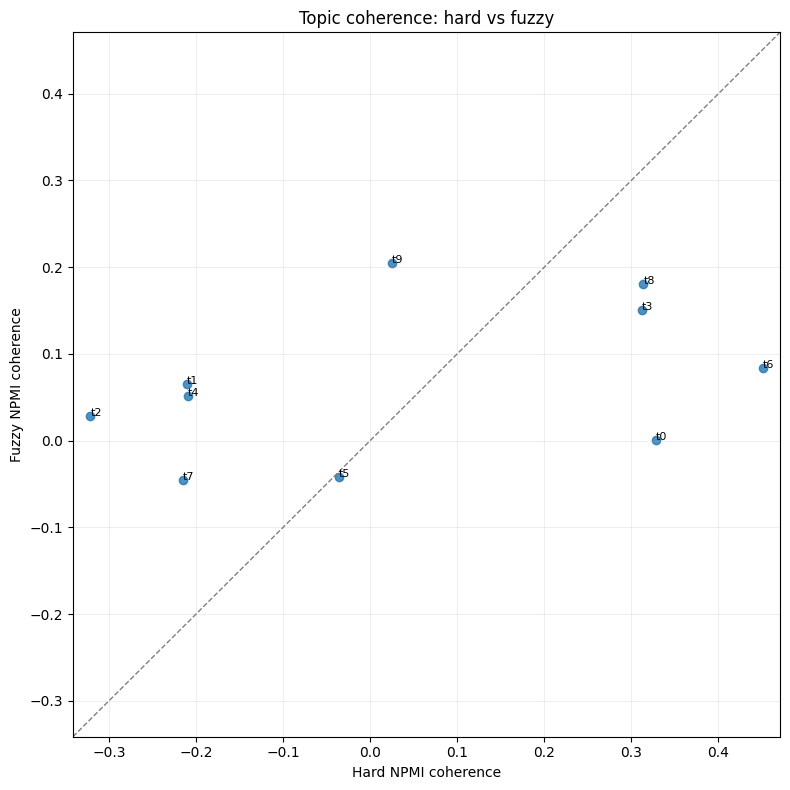

Mean hard NPMI : 0.043847563858814255
Mean fuzzy NPMI: 0.06763365862737195


In [24]:
# Визуальное сравнение когерентности hard vs fuzzy
plot_df = coh_df.dropna(subset=['hard_npmi', 'fuzzy_npmi']).copy()

plt.figure(figsize=(8, 8))
plt.scatter(plot_df['hard_npmi'], plot_df['fuzzy_npmi'], alpha=0.8)

lims = [
    min(plot_df['hard_npmi'].min(), plot_df['fuzzy_npmi'].min()) - 0.02,
    max(plot_df['hard_npmi'].max(), plot_df['fuzzy_npmi'].max()) + 0.02,
]
plt.plot(lims, lims, '--', color='gray', linewidth=1)
for _, r in plot_df.iterrows():
    plt.text(r['hard_npmi'], r['fuzzy_npmi'], f"t{int(r['topic_id'])}", fontsize=8)

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Hard NPMI coherence')
plt.ylabel('Fuzzy NPMI coherence')
plt.title('Topic coherence: hard vs fuzzy')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('Mean hard NPMI :', np.nanmean(coh_df['hard_npmi']))
print('Mean fuzzy NPMI:', np.nanmean(coh_df['fuzzy_npmi']))

In [25]:
# --- Дополнительные метрики в духе статьи: Document similarity / Semantic coherence / Semantic diversity ---
# ВНИМАНИЕ: эта ячейка использует sentence-transformers и может быть ресурсоемкой.

from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = SCRIPT_EMBEDDING_MODEL
TOP_WORDS_FOR_SEMANTIC_METRICS = SCRIPT_TOP_WORDS
DOC_SIM_TOP_N = 3                     # z_n: fixed number of top topics per document (paper-style)
SEM_COH_WINDOW_SIZE = 20              # Sliding window для virtual documents
SEM_COH_THRESHOLD = 0.55              # ct в статье
SEM_DIV_THRESHOLD = 0.80              # dt в статье


def build_virtual_docs(tokens: list[str], window_size: int) -> list[list[str]]:
    if not tokens:
        return []
    if len(tokens) <= window_size:
        return [tokens]
    return [tokens[i:i + window_size] for i in range(0, len(tokens) - window_size + 1)]


# 1) Подготовка тем (top words и строка темы)
topic_top_words = {
    int(r['topic_id']): list(r.get('top_words', []))[:TOP_WORDS_FOR_SEMANTIC_METRICS]
    for r in topic_rows
}
topic_texts = {
    tid: ' '.join(words) if words else f'topic_{tid}'
    for tid, words in topic_top_words.items()
}

# 2) Подготовка документов
docs_clean = df_docs.get('review_text_clean', pd.Series([''] * n_docs)).fillna('').astype(str).tolist()

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

def get_word_embeddings(words: list[str]) -> np.ndarray:
    """Use cached term embeddings when possible, encode only missing words."""
    if not words:
        return np.zeros((0, 1), dtype=float)

    out = np.zeros((len(words), len(next(iter(cached_term_embedding_by_term.values()))) if cached_term_embedding_by_term else 0), dtype=float)
    missing_words: list[str] = []
    missing_positions: list[int] = []

    for i, w in enumerate(words):
        emb = cached_term_embedding_by_term.get(w)
        if emb is None:
            missing_words.append(w)
            missing_positions.append(i)
        else:
            if out.shape[1] == 0:
                out = np.zeros((len(words), len(emb)), dtype=float)
            out[i] = emb

    if missing_words:
        miss_emb = embedder.encode(
            missing_words,
            normalize_embeddings=True,
            batch_size=SCRIPT_TERM_EMBEDDING_BATCH_SIZE,
        )
        miss_emb = np.asarray(miss_emb, dtype=float)
        if out.shape[1] == 0:
            out = np.zeros((len(words), miss_emb.shape[1]), dtype=float)
        for pos, emb in zip(missing_positions, miss_emb):
            out[pos] = emb

    return out


topic_ids_sorted = sorted(topic_texts.keys())
topic_matrix = embedder.encode(
    [topic_texts[tid] for tid in topic_ids_sorted],
    normalize_embeddings=True,
    batch_size=SCRIPT_TERM_EMBEDDING_BATCH_SIZE,
)
topic_id_to_pos = {tid: i for i, tid in enumerate(topic_ids_sorted)}

if cached_doc_embeddings is not None:
    doc_matrix = cached_doc_embeddings
    print('Using cached doc embeddings for paper metrics.')
else:
    doc_matrix = embedder.encode(
        docs_clean,
        normalize_embeddings=True,
        batch_size=SCRIPT_DOC_EMBEDDING_BATCH_SIZE,
    )
    print('Cached doc embeddings not found, embeddings computed for paper metrics.')

# ========== A) Document similarity ==========
doc_sim_values: list[float] = []
for i in range(n_docs):
    m = membership[i]
    top_ids = np.argsort(-m)[: max(1, min(DOC_SIM_TOP_N, n_topics))].tolist()

    valid_top_ids = [tid for tid in top_ids if tid in topic_id_to_pos]
    if not valid_top_ids:
        continue

    d = doc_matrix[i:i + 1]
    sims = [
        float(cosine_similarity(d, topic_matrix[topic_id_to_pos[tid]:topic_id_to_pos[tid] + 1])[0, 0])
        for tid in valid_top_ids
    ]
    if sims:
        # Eq. (8): average by z_n for each document, then average across docs.
        doc_sim_values.append(float(np.mean(sims)))

paper_document_similarity = float(np.mean(doc_sim_values)) if doc_sim_values else float('nan')

# ========== B) Semantic coherence ==========
# Реализация paper-style идеи: hit, если max cosine(topic_word, words_in_virtual_doc) >= ct.

# Подготовка virtual documents
virtual_docs: list[list[str]] = []
for toks in doc_tokens:
    virtual_docs.extend(build_virtual_docs(toks, SEM_COH_WINDOW_SIZE))

# Уникальные слова virtual docs + их эмбеддинги
virtual_vocab = sorted({w for vd in virtual_docs for w in vd})
if virtual_vocab:
    virtual_vocab_emb = get_word_embeddings(virtual_vocab)
    vw_to_idx = {w: i for i, w in enumerate(virtual_vocab)}
else:
    virtual_vocab_emb = np.zeros((0, 1), dtype=float)
    vw_to_idx = {}


def topic_word_hits_in_virtual_docs(topic_words: list[str], threshold: float) -> dict[str, np.ndarray]:
    hits: dict[str, np.ndarray] = {}
    if not virtual_docs:
        for w in topic_words:
            hits[w] = np.zeros(0, dtype=int)
        return hits

    # эмбеддинги слов темы
    tw_unique = sorted(set(topic_words))
    tw_emb = get_word_embeddings(tw_unique) if tw_unique else np.zeros((0, 1))
    tw_emb_map = {w: tw_emb[i:i + 1] for i, w in enumerate(tw_unique)}

    for w in topic_words:
        w_emb = tw_emb_map.get(w)
        cur_hits = np.zeros(len(virtual_docs), dtype=int)
        if w_emb is None:
            hits[w] = cur_hits
            continue

        for vi, vd in enumerate(virtual_docs):
            idxs = [vw_to_idx[t] for t in vd if t in vw_to_idx]
            if not idxs:
                continue
            local = virtual_vocab_emb[idxs]
            max_sim = float(np.max(cosine_similarity(w_emb, local)))
            cur_hits[vi] = int(max_sim >= threshold)

        hits[w] = cur_hits

    return hits


def semantic_coherence_for_topic(topic_words: list[str], threshold: float, eps: float = 1e-12) -> float:
    words = list(topic_words)
    if len(words) < 2 or not virtual_docs:
        return float('nan')

    hits = topic_word_hits_in_virtual_docs(words, threshold)
    vn = float(len(virtual_docs))

    npmis: list[float] = []
    for wi, wj in combinations(words, 2):
        hi = hits[wi]
        hj = hits[wj]

        p_wi = float(np.sum(hi) / vn)
        p_wj = float(np.sum(hj) / vn)
        p_ij = float(np.sum((hi == 1) & (hj == 1)) / vn)

        p_wi = float(np.clip(p_wi, eps, 1.0 - eps))
        p_wj = float(np.clip(p_wj, eps, 1.0 - eps))
        p_ij = float(np.clip(p_ij, eps, 1.0 - eps))

        pmi = math.log(p_ij / (p_wi * p_wj))
        denom = -math.log(p_ij)
        if abs(denom) < eps:
            continue
        npmi = pmi / denom
        npmis.append(npmi)

    return float(np.mean(npmis)) if npmis else float('nan')


sem_coh_rows = []
for tid in topic_ids_sorted:
    sc = semantic_coherence_for_topic(topic_top_words.get(tid, []), SEM_COH_THRESHOLD)
    sem_coh_rows.append({'topic_id': tid, 'semantic_coherence': sc})

sem_coh_df = pd.DataFrame(sem_coh_rows)
paper_semantic_coherence = float(np.nanmean(sem_coh_df['semantic_coherence']))

# ========== C) Semantic diversity ==========
all_topic_words = [w for tid in topic_ids_sorted for w in topic_top_words.get(tid, [])]
if all_topic_words:
    aw_emb = get_word_embeddings(all_topic_words)
    tw = len(all_topic_words)
    if tw < 2:
        paper_semantic_diversity = float('nan')
    else:
        sim_mx = cosine_similarity(aw_emb)
        non_duplicate_pairs = 0
        for i in range(tw - 1):
            for j in range(i + 1, tw):
                # Eq. (20): count 1 when Sim(w_i, w_j) <= d_t, else 0.
                non_duplicate_pairs += int(sim_mx[i, j] <= SEM_DIV_THRESHOLD)

        paper_semantic_diversity = float((2.0 / (tw * (tw - 1))) * non_duplicate_pairs)
else:
    paper_semantic_diversity = float('nan')

paper_metrics_df = pd.DataFrame(
    [
        {
            'document_similarity': paper_document_similarity,
            'semantic_coherence': paper_semantic_coherence,
            'semantic_diversity': paper_semantic_diversity,
            'embedding_model': EMBEDDING_MODEL_NAME,
            'script_top_words': SCRIPT_TOP_WORDS,
            'script_seed': SCRIPT_SEED,
            'script_umap_neighbors': SCRIPT_UMAP_NEIGHBORS,
            'script_umap_components': SCRIPT_UMAP_COMPONENTS,
            'script_umap_min_dist': SCRIPT_UMAP_MIN_DIST,
            'script_umap_metric': SCRIPT_UMAP_METRIC,
            'script_umap_init': SCRIPT_UMAP_INIT,
            'script_fcm_m': SCRIPT_FCM_M,
            'script_fcm_max_iter': SCRIPT_FCM_MAX_ITER,
            'script_doc_embedding_batch_size': SCRIPT_DOC_EMBEDDING_BATCH_SIZE,
            'script_term_embedding_batch_size': SCRIPT_TERM_EMBEDDING_BATCH_SIZE,
            'script_min_df': SCRIPT_MIN_DF,
            'script_max_vocab_size': SCRIPT_MAX_VOCAB_SIZE,
            'script_absent_similarity': SCRIPT_ABSENT_SIMILARITY,
            'doc_sim_top_n': DOC_SIM_TOP_N,
            'semantic_coh_threshold': SEM_COH_THRESHOLD,
            'semantic_div_threshold': SEM_DIV_THRESHOLD,
            'virtual_docs_count': len(virtual_docs),
        }
    ]
)

paper_metrics_df

Using cached doc embeddings for paper metrics.


,document_similarity,semantic_coherence,semantic_diversity,embedding_model,script_top_words,script_seed,script_umap_neighbors,script_umap_components,script_umap_min_dist,script_umap_metric,...,script_fcm_max_iter,script_doc_embedding_batch_size,script_term_embedding_batch_size,script_min_df,script_max_vocab_size,script_absent_similarity,doc_sim_top_n,semantic_coh_threshold,semantic_div_threshold,virtual_docs_count
0,0.456075,0.019179,0.977374,deepvk/USER-bge-m3,10,42,15,5,0.0,cosine,...,300,2,2,2,20000,-2.0,3,0.55,0.8,35076


In [26]:
# Таблица semantic coherence по темам (paper-style)
sem_coh_df.sort_values('semantic_coherence', ascending=False).reset_index(drop=True).head(20)

,topic_id,semantic_coherence
0,3,0.038987
1,2,0.031667
2,0,0.026954
3,5,0.017220
4,9,0.016046
5,8,0.013483
6,7,0.012899
7,6,0.012437
8,4,0.011377
9,1,0.010716


In [27]:
# Опционально: сохранить итоговые paper-style метрики
PAPER_METRICS_CSV = DOC_TOPICS_PATH.with_name('paper_style_fuzzy_metrics.csv')
PAPER_TOPIC_COH_CSV = DOC_TOPICS_PATH.with_name('paper_style_topic_semantic_coherence.csv')

paper_metrics_df.to_csv(PAPER_METRICS_CSV, index=False)
sem_coh_df.to_csv(PAPER_TOPIC_COH_CSV, index=False)

PAPER_METRICS_CSV, PAPER_TOPIC_COH_CSV

(PosixPath('paper_output_preprocessed/paper_style_fuzzy_metrics.csv'),
 PosixPath('paper_output_preprocessed/paper_style_topic_semantic_coherence.csv'))

In [28]:
# Опционально: сохранить таблицу метрик
OUT_CSV = DOC_TOPICS_PATH.with_name('paper_topic_coherence_fuzzy_analysis.csv')
coh_df.to_csv(OUT_CSV, index=False)
OUT_CSV

PosixPath('paper_output_preprocessed/paper_topic_coherence_fuzzy_analysis.csv')

In [29]:
# LDA baseline on the same corpus in two modes:
# 1) with lemmatization
# 2) without lemmatization
# Other settings are identical to fuzzy pipeline (vectorizer params + top words count).

from gensim.models import LdaModel
from gensim.corpora import Dictionary
from sklearn.feature_extraction.text import CountVectorizer
from fuzzy_bertopic_paper_pipeline import _build_russian_stop_words

LDA_NUM_TOPICS = SCRIPT_NUM_TOPICS_REQUESTED
LDA_TOP_WORDS = SCRIPT_TOP_WORDS

# 1) Same corpus (with fallback to raw)
lda_docs = (
    df_docs.get('review_text_clean', pd.Series([''] * len(df_docs)))
    .fillna('')
    .astype(str)
    .tolist()
)
if any(not d.strip() for d in lda_docs):
    raw_fallback = (
        df_docs.get('review_text_raw', pd.Series([''] * len(df_docs)))
        .fillna('')
        .astype(str)
        .tolist()
    )
    lda_docs = [d.strip() if d.strip() else r.strip() for d, r in zip(lda_docs, raw_fallback)]

TOKEN_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9_]+")

# Lemmatizer with robust fallback
try:
    import pymorphy3 as _pymorphy
    morph = _pymorphy.MorphAnalyzer()
    _lemmatizer_name = 'pymorphy3'
except Exception:
    try:
        import pymorphy2 as _pymorphy
        morph = _pymorphy.MorphAnalyzer()
        _lemmatizer_name = 'pymorphy2'
    except Exception:
        morph = None
        _lemmatizer_name = None


def _lemmatize_token(tok: str) -> str:
    if morph is None:
        return tok.lower()
    return morph.parse(tok.lower())[0].normal_form


def preprocess_text_for_lda(text: str, lemmatize: bool) -> str:
    toks = TOKEN_RE.findall(text)
    if lemmatize:
        toks = [_lemmatize_token(t) for t in toks if t]
    else:
        toks = [t.lower() for t in toks if t]
    return ' '.join(toks)


def _sparse_row_to_bow(row) -> list[tuple[int, int]]:
    return [(int(i), int(v)) for i, v in zip(row.indices, row.data) if v > 0]


def run_lda_variant(docs: list[str], lemmatize: bool) -> tuple[pd.DataFrame, np.ndarray, dict]:
    docs_proc = [preprocess_text_for_lda(t, lemmatize=lemmatize) for t in docs]

    russian_stop_words = _build_russian_stop_words()
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=russian_stop_words if russian_stop_words else None,
        ngram_range=(1, 2),
        # Exclude pure numbers and numeric-like tokens: keep only tokens that contain at least one letter.
        token_pattern=r"(?u)\b(?=\w*[A-Za-zА-Яа-яЁё])\w+\b",
        min_df=max(1, SCRIPT_MIN_DF),
        max_features=SCRIPT_MAX_VOCAB_SIZE if SCRIPT_MAX_VOCAB_SIZE > 0 else None,
    )

    X = vectorizer.fit_transform(docs_proc)
    terms = vectorizer.get_feature_names_out().tolist()

    # Build gensim id2word aligned with CountVectorizer vocabulary indices.
    id2word = Dictionary()
    id2word.token2id = {t: i for i, t in enumerate(terms)}
    id2word.id2token = {i: t for i, t in enumerate(terms)}

    corpus = [_sparse_row_to_bow(X.getrow(i)) for i in range(X.shape[0])]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=LDA_NUM_TOPICS,
        random_state=SCRIPT_SEED,
        passes=20,
        iterations=200,
        eval_every=None,
        minimum_probability=0.0,
    )

    # Full dense doc-topic matrix (n_docs x n_topics)
    doc_topic = np.zeros((len(corpus), LDA_NUM_TOPICS), dtype=float)
    for di, dist in enumerate(lda_model.get_document_topics(corpus, minimum_probability=0.0)):
        for tid, prob in dist:
            doc_topic[di, int(tid)] = float(prob)

    topic_rows_local = []
    for topic_id in range(LDA_NUM_TOPICS):
        term_probs = lda_model.get_topic_terms(topic_id, topn=LDA_TOP_WORDS)
        words = [id2word[int(term_id)] for term_id, _ in term_probs]
        weights = [float(prob) for _, prob in term_probs]
        topic_rows_local.append(
            {
                'topic_id': int(topic_id),
                'top_words': words,
                'top_word_weights': weights,
                'topic_size_soft': float(doc_topic[:, topic_id].sum()),
            }
        )

    topic_df_local = pd.DataFrame(topic_rows_local).sort_values('topic_size_soft', ascending=False).reset_index(drop=True)
    meta = {
        'backend': 'gensim',
        'lemmatize': lemmatize,
        'lemmatizer': _lemmatizer_name if lemmatize else 'disabled',
        'dtm_shape': X.shape,
        'vocab_size': int(len(terms)),
        'passes': 20,
        'iterations': 200,
    }
    artifacts = {
        'lda_model': lda_model,
        'corpus': corpus,
        'id2word': id2word,
    }
    return topic_df_local, np.asarray(doc_topic, dtype=float), meta, artifacts


lda_topic_df_lem, lda_doc_topic_lem, lda_meta_lem, lda_artifacts_lem = run_lda_variant(lda_docs, lemmatize=True)
lda_topic_df_raw, lda_doc_topic_raw, lda_meta_raw, lda_artifacts_raw = run_lda_variant(lda_docs, lemmatize=False)

# Convenience aliases for visualization cell
lda_model_lem, lda_corpus_lem, lda_id2word_lem = (
    lda_artifacts_lem['lda_model'],
    lda_artifacts_lem['corpus'],
    lda_artifacts_lem['id2word'],
)
lda_model_raw, lda_corpus_raw, lda_id2word_raw = (
    lda_artifacts_raw['lda_model'],
    lda_artifacts_raw['corpus'],
    lda_artifacts_raw['id2word'],
)

pd.DataFrame([lda_meta_lem, lda_meta_raw])

,backend,lemmatize,lemmatizer,dtm_shape,vocab_size,passes,iterations
0,gensim,True,pymorphy3,"(191, 3930)",3930,20,200
1,gensim,False,disabled,"(191, 4561)",4561,20,200


In [30]:
# LDA visualization from gensim ecosystem (pyLDAvis)
# Classic intertopic circle map + term bars.

from IPython.display import display

try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    _HAS_PYLDAVIS = True
except Exception as exc:
    _HAS_PYLDAVIS = False
    print(f'pyLDAvis is unavailable ({exc}). Install with: pip install pyldavis')

if _HAS_PYLDAVIS:
    lda_vis = gensimvis.prepare(
        topic_model=lda_model_raw,
        corpus=lda_corpus_raw,
        dictionary=lda_id2word_raw,
        sort_topics=False,
    )
    display(pyLDAvis.display(lda_vis))

    # Optional export
    # pyLDAvis.save_html(lda_vis, 'lda_vis_raw.html')

In [31]:
# LDA coherence: same fuzzy NPMI formulation, with and without lemmatization

def lda_fuzzy_npmi_df(lda_topic_df: pd.DataFrame, lda_doc_topic: np.ndarray, variant_name: str) -> pd.DataFrame:
    lda_membership = np.asarray(lda_doc_topic, dtype=float)
    row_sums = lda_membership.sum(axis=1, keepdims=True)
    row_sums = np.where(np.isclose(row_sums, 0.0), 1.0, row_sums)
    lda_membership = lda_membership / row_sums

    rows = []
    for _, r in lda_topic_df.iterrows():
        tid = int(r['topic_id'])
        topic_words = list(r['top_words'])

        fuzzy_npmi = topic_npmi_fuzzy(tid, topic_words, doc_token_sets, lda_membership)
        rows.append(
            {
                'variant': variant_name,
                'topic_id': tid,
                'topic_size_soft': float(lda_membership[:, tid].sum()),
                'fuzzy_npmi': fuzzy_npmi,
                'top_words': ', '.join(topic_words[:LDA_TOP_WORDS]),
            }
        )

    return pd.DataFrame(rows)


lda_coh_df_lem = lda_fuzzy_npmi_df(lda_topic_df_lem, lda_doc_topic_lem, 'with_lemmatization')
lda_coh_df_raw = lda_fuzzy_npmi_df(lda_topic_df_raw, lda_doc_topic_raw, 'without_lemmatization')
lda_coh_df = pd.concat([lda_coh_df_lem, lda_coh_df_raw], ignore_index=True)

summary = (
    lda_coh_df.groupby('variant', as_index=False)['fuzzy_npmi']
    .mean()
    .rename(columns={'fuzzy_npmi': 'mean_lda_fuzzy_npmi'})
    .sort_values('mean_lda_fuzzy_npmi', ascending=False)
)
summary

,variant,mean_lda_fuzzy_npmi
1,without_lemmatization,0.265773
0,with_lemmatization,-0.262021


In [32]:
# Topic-level details for both variants
pd.set_option('display.max_colwidth', None)
lda_coh_df.sort_values(['variant', 'fuzzy_npmi'], ascending=[True, False]).head(40)

,variant,topic_id,topic_size_soft,fuzzy_npmi,top_words
5,with_lemmatization,9,18.029392,0.026941,"язык, русский, сопроводительный, русский язык, качество, понятие, хороший, мысль, проблема, научный"
0,with_lemmatization,1,31.723813,-0.166915,"тема, качество, теоретический, эмпирический, академический, российский, ясность, хороший, широкий, язык"
3,with_lemmatization,8,22.126867,-0.177271,"балл, теоретический, хороший, взгляд, популярный, социальный, научно, общий, наука, сельский"
4,with_lemmatization,3,19.599276,-0.184293,"глава, анализ, социальный, развитие, проблема, часть, место, политический, научный, отношение"
2,with_lemmatization,7,23.454733,-0.209221,"свой, социальный, читатель, вывод, оценка, дать, сектор, данные, язык, уровень"
1,with_lemmatization,0,23.707607,-0.333382,"язык, научный, русский, мода, написать, труд, теоретический, интересный, анализ, социальный"
6,with_lemmatization,2,17.839001,-0.346826,"социальный, россия, раздел, глава, плюснин, часть, общество, город, российский, современный"
8,with_lemmatization,4,12.788776,-0.379525,"глава, война, повседневность, советский, история, академический, смысл, уровень, свой, дать"
7,with_lemmatization,5,16.212787,-0.399879,"город, университет, дать, молодёжь, русский, высокий, глава, мир, проблема, современный"
9,with_lemmatization,6,5.517746,-0.449834,"понимание, оригинал, смысл, теория, социальный, современный, самый, культура, случай, общество"


In [33]:
# LDA (without lemmatization): paper-style metrics
# - Document similarity
# - Semantic coherence
# - Semantic diversity

from sentence_transformers import SentenceTransformer

# Reuse the same constants as BERTopic paper-style block
EMBEDDING_MODEL_NAME = SCRIPT_EMBEDDING_MODEL

# LDA membership (without lemmatization), normalized
lda_membership_raw = np.asarray(lda_doc_topic_raw, dtype=float)
row_sums = lda_membership_raw.sum(axis=1, keepdims=True)
row_sums = np.where(np.isclose(row_sums, 0.0), 1.0, row_sums)
lda_membership_raw = lda_membership_raw / row_sums

# Topic words/texts from the LDA no-lemma run
lda_topic_top_words_raw = {
    int(r['topic_id']): list(r.get('top_words', []))[:TOP_WORDS_FOR_SEMANTIC_METRICS]
    for r in lda_topic_df_raw.to_dict('records')
}
lda_topic_texts_raw = {
    tid: ' '.join(words) if words else f'topic_{tid}'
    for tid, words in lda_topic_top_words_raw.items()
}

# Same documents as in BERTopic metric block
lda_docs_clean = df_docs.get('review_text_clean', pd.Series([''] * n_docs)).fillna('').astype(str).tolist()

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)


def lda_get_word_embeddings(words: list[str]) -> np.ndarray:
    """Use cached term embeddings when available; encode missing words."""
    if not words:
        return np.zeros((0, 1), dtype=float)

    out = np.zeros((len(words), len(next(iter(cached_term_embedding_by_term.values()))) if cached_term_embedding_by_term else 0), dtype=float)
    missing_words: list[str] = []
    missing_positions: list[int] = []

    for i, w in enumerate(words):
        emb = cached_term_embedding_by_term.get(w)
        if emb is None:
            missing_words.append(w)
            missing_positions.append(i)
        else:
            if out.shape[1] == 0:
                out = np.zeros((len(words), len(emb)), dtype=float)
            out[i] = emb

    if missing_words:
        miss_emb = embedder.encode(
            missing_words,
            normalize_embeddings=True,
            batch_size=SCRIPT_TERM_EMBEDDING_BATCH_SIZE,
        )
        miss_emb = np.asarray(miss_emb, dtype=float)
        if out.shape[1] == 0:
            out = np.zeros((len(words), miss_emb.shape[1]), dtype=float)
        for pos, emb in zip(missing_positions, miss_emb):
            out[pos] = emb

    return out


lda_topic_ids_sorted = sorted(lda_topic_texts_raw.keys())
lda_topic_matrix = embedder.encode(
    [lda_topic_texts_raw[tid] for tid in lda_topic_ids_sorted],
    normalize_embeddings=True,
    batch_size=SCRIPT_TERM_EMBEDDING_BATCH_SIZE,
)
lda_topic_id_to_pos = {tid: i for i, tid in enumerate(lda_topic_ids_sorted)}

if cached_doc_embeddings is not None:
    lda_doc_matrix = cached_doc_embeddings
else:
    lda_doc_matrix = embedder.encode(
        lda_docs_clean,
        normalize_embeddings=True,
        batch_size=SCRIPT_DOC_EMBEDDING_BATCH_SIZE,
    )

# A) Document similarity
lda_doc_sim_values: list[float] = []
for i in range(n_docs):
    m = lda_membership_raw[i]
    top_ids = np.argsort(-m)[: max(1, min(DOC_SIM_TOP_N, m.shape[0]))].tolist()

    valid_top_ids = [tid for tid in top_ids if tid in lda_topic_id_to_pos]
    if not valid_top_ids:
        continue

    d = lda_doc_matrix[i:i + 1]
    sims = [
        float(cosine_similarity(d, lda_topic_matrix[lda_topic_id_to_pos[tid]:lda_topic_id_to_pos[tid] + 1])[0, 0])
        for tid in valid_top_ids
    ]
    if sims:
        # Eq. (8): average by z_n for each document, then average across docs.
        lda_doc_sim_values.append(float(np.mean(sims)))

lda_document_similarity = float(np.mean(lda_doc_sim_values)) if lda_doc_sim_values else float('nan')

# B) Semantic coherence
lda_virtual_docs: list[list[str]] = []
for toks in doc_tokens:
    lda_virtual_docs.extend(build_virtual_docs(toks, SEM_COH_WINDOW_SIZE))

lda_virtual_vocab = sorted({w for vd in lda_virtual_docs for w in vd})
if lda_virtual_vocab:
    lda_virtual_vocab_emb = lda_get_word_embeddings(lda_virtual_vocab)
    lda_vw_to_idx = {w: i for i, w in enumerate(lda_virtual_vocab)}
else:
    lda_virtual_vocab_emb = np.zeros((0, 1), dtype=float)
    lda_vw_to_idx = {}


def lda_topic_word_hits_in_virtual_docs(topic_words: list[str], threshold: float) -> dict[str, np.ndarray]:
    hits: dict[str, np.ndarray] = {}
    if not lda_virtual_docs:
        for w in topic_words:
            hits[w] = np.zeros(0, dtype=int)
        return hits

    tw_unique = sorted(set(topic_words))
    tw_emb = lda_get_word_embeddings(tw_unique) if tw_unique else np.zeros((0, 1))
    tw_emb_map = {w: tw_emb[i:i + 1] for i, w in enumerate(tw_unique)}

    for w in topic_words:
        w_emb = tw_emb_map.get(w)
        cur_hits = np.zeros(len(lda_virtual_docs), dtype=int)
        if w_emb is None:
            hits[w] = cur_hits
            continue

        for vi, vd in enumerate(lda_virtual_docs):
            idxs = [lda_vw_to_idx[t] for t in vd if t in lda_vw_to_idx]
            if not idxs:
                continue
            local = lda_virtual_vocab_emb[idxs]
            max_sim = float(np.max(cosine_similarity(w_emb, local)))
            cur_hits[vi] = int(max_sim >= SEM_COH_THRESHOLD)

        hits[w] = cur_hits

    return hits


def lda_semantic_coherence_for_topic(topic_words: list[str], eps: float = 1e-12) -> float:
    words = list(topic_words)
    if len(words) < 2 or not lda_virtual_docs:
        return float('nan')

    hits = lda_topic_word_hits_in_virtual_docs(words, SEM_COH_THRESHOLD)
    vn = float(len(lda_virtual_docs))

    npmis: list[float] = []
    for wi, wj in combinations(words, 2):
        hi = hits[wi]
        hj = hits[wj]

        p_wi = float(np.sum(hi) / vn)
        p_wj = float(np.sum(hj) / vn)
        p_ij = float(np.sum((hi == 1) & (hj == 1)) / vn)

        p_wi = float(np.clip(p_wi, eps, 1.0 - eps))
        p_wj = float(np.clip(p_wj, eps, 1.0 - eps))
        p_ij = float(np.clip(p_ij, eps, 1.0 - eps))

        pmi = math.log(p_ij / (p_wi * p_wj))
        denom = -math.log(p_ij)
        if abs(denom) < eps:
            continue
        npmi = pmi / denom
        npmis.append(npmi)

    return float(np.mean(npmis)) if npmis else float('nan')


lda_sem_coh_rows = []
for tid in lda_topic_ids_sorted:
    sc = lda_semantic_coherence_for_topic(lda_topic_top_words_raw.get(tid, []))
    lda_sem_coh_rows.append({'topic_id': tid, 'semantic_coherence': sc})

lda_sem_coh_df = pd.DataFrame(lda_sem_coh_rows)
lda_semantic_coherence = float(np.nanmean(lda_sem_coh_df['semantic_coherence']))

# C) Semantic diversity
lda_all_topic_words = [w for tid in lda_topic_ids_sorted for w in lda_topic_top_words_raw.get(tid, [])]
if lda_all_topic_words:
    lda_aw_emb = lda_get_word_embeddings(lda_all_topic_words)
    tw = len(lda_all_topic_words)
    if tw < 2:
        lda_semantic_diversity = float('nan')
    else:
        sim_mx = cosine_similarity(lda_aw_emb)
        non_duplicate_pairs = 0
        for i in range(tw - 1):
            for j in range(i + 1, tw):
                # Eq. (20): count 1 when Sim(w_i, w_j) <= d_t, else 0.
                non_duplicate_pairs += int(sim_mx[i, j] <= SEM_DIV_THRESHOLD)

        lda_semantic_diversity = float((2.0 / (tw * (tw - 1))) * non_duplicate_pairs)
else:
    lda_semantic_diversity = float('nan')

lda_raw_paper_metrics_df = pd.DataFrame([
    {
        'variant': 'LDA_without_lemmatization',
        'document_similarity': lda_document_similarity,
        'semantic_coherence': lda_semantic_coherence,
        'semantic_diversity': lda_semantic_diversity,
        'embedding_model': EMBEDDING_MODEL_NAME,
        'script_top_words': SCRIPT_TOP_WORDS,
        'script_seed': SCRIPT_SEED,
        'script_min_df': SCRIPT_MIN_DF,
        'script_max_vocab_size': SCRIPT_MAX_VOCAB_SIZE,
        'script_absent_similarity': SCRIPT_ABSENT_SIMILARITY,
        'doc_sim_top_n': DOC_SIM_TOP_N,
        'semantic_coh_threshold': SEM_COH_THRESHOLD,
        'semantic_div_threshold': SEM_DIV_THRESHOLD,
        'virtual_docs_count': len(lda_virtual_docs),
    }
])

lda_raw_paper_metrics_df

,variant,document_similarity,semantic_coherence,semantic_diversity,embedding_model,script_top_words,script_seed,script_min_df,script_max_vocab_size,script_absent_similarity,doc_sim_top_n,semantic_coh_threshold,semantic_div_threshold,virtual_docs_count
0,LDA_without_lemmatization,0.458339,0.026511,0.990303,deepvk/USER-bge-m3,10,42,2,20000,-2.0,3,0.55,0.8,35076


In [34]:
# Side-by-side: BERTopic paper metrics vs LDA (without lemmatization) paper metrics
compare_cols = ['document_similarity', 'semantic_coherence', 'semantic_diversity']

bertopic_metrics = paper_metrics_df.copy()
bertopic_metrics.insert(0, 'variant', 'BERTopic_fuzzy')

comparison_df = pd.concat(
    [
        bertopic_metrics[['variant'] + compare_cols],
        lda_raw_paper_metrics_df[['variant'] + compare_cols],
    ],
    ignore_index=True,
)
comparison_df

,variant,document_similarity,semantic_coherence,semantic_diversity
0,BERTopic_fuzzy,0.456075,0.019179,0.977374
1,LDA_without_lemmatization,0.458339,0.026511,0.990303


In [35]:
# C_v coherence for both models (BERTopic and LDA variants)
# Includes:
# - BERTopic_fuzzy
# - LDA_without_lemmatization

try:
    from gensim import corpora
    from gensim.models import CoherenceModel
    _HAS_GENSIM = True
except Exception as exc:
    corpora = None
    CoherenceModel = None
    _HAS_GENSIM = False
    print(f"gensim is unavailable ({exc}). C_v will be NaN.")

TOKEN_RE_CV = re.compile(r"[A-Za-zА-Яа-яЁё0-9_]+")

# ---------- Helpers ----------
try:
    import pymorphy3 as _pymorphy_cv
    _morph_cv = _pymorphy_cv.MorphAnalyzer()
except Exception:
    try:
        import pymorphy2 as _pymorphy_cv
        _morph_cv = _pymorphy_cv.MorphAnalyzer()
    except Exception:
        _morph_cv = None


def _lemma_or_lower(tok: str, lemmatize: bool) -> str:
    t = tok.lower()
    if not lemmatize or _morph_cv is None:
        return t
    return _morph_cv.parse(t)[0].normal_form


def _docs_to_texts_for_cv(docs: list[str], lemmatize: bool) -> list[list[str]]:
    texts = []
    for doc in docs:
        toks = TOKEN_RE_CV.findall(doc if isinstance(doc, str) else "")
        toks = [_lemma_or_lower(t, lemmatize=lemmatize) for t in toks if t]
        # Add bigrams as separate tokens, because top_words can contain "w1 w2"
        bigrams = [f"{a} {b}" for a, b in zip(toks[:-1], toks[1:])]
        texts.append(toks + bigrams)
    return texts


def _model_cv(topics_df: pd.DataFrame, texts_for_cv: list[list[str]], top_n_words: int) -> float:
    if not _HAS_GENSIM:
        return float('nan')

    dictionary = corpora.Dictionary(texts_for_cv)
    topics = [list(r['top_words'])[:top_n_words] for _, r in topics_df.iterrows()]
    # keep only words present in dictionary
    topics = [[w for w in topic if w in dictionary.token2id] for topic in topics]
    topics = [t for t in topics if len(t) >= 2]
    if not topics:
        return float('nan')

    cm = CoherenceModel(
        topics=topics,
        texts=texts_for_cv,
        dictionary=dictionary,
        coherence='c_v',
    )
    return float(cm.get_coherence())


# ---------- Build same source corpus ----------
docs_src = (
    df_docs.get('review_text_clean', pd.Series([''] * len(df_docs)))
    .fillna('')
    .astype(str)
    .tolist()
)
if any(not d.strip() for d in docs_src):
    raw_fallback = (
        df_docs.get('review_text_raw', pd.Series([''] * len(df_docs)))
        .fillna('')
        .astype(str)
        .tolist()
    )
    docs_src = [d.strip() if d.strip() else r.strip() for d, r in zip(docs_src, raw_fallback)]

texts_cv_bertopic = _docs_to_texts_for_cv(docs_src, lemmatize=False)
texts_cv_lda_raw = _docs_to_texts_for_cv(docs_src, lemmatize=False)
texts_cv_lda_lem = _docs_to_texts_for_cv(docs_src, lemmatize=True)

bertopic_topics_df = pd.DataFrame(topic_rows)

cv_rows = [
    {
        'variant': 'BERTopic_fuzzy',
        'cv_coherence': _model_cv(bertopic_topics_df, texts_cv_bertopic, SCRIPT_TOP_WORDS),
    },
    {
        'variant': 'LDA_without_lemmatization',
        'cv_coherence': _model_cv(lda_topic_df_raw, texts_cv_lda_raw, LDA_TOP_WORDS),
    },
]

cv_summary_df = pd.DataFrame(cv_rows).sort_values('cv_coherence', ascending=False).reset_index(drop=True)
cv_summary_df

,variant,cv_coherence
0,LDA_without_lemmatization,0.510573
1,BERTopic_fuzzy,0.405528


In [36]:
# Combined comparison: paper-style metrics + C_v
comparison_with_cv_df = comparison_df.merge(cv_summary_df, on='variant', how='left')
comparison_with_cv_df

,variant,document_similarity,semantic_coherence,semantic_diversity,cv_coherence
0,BERTopic_fuzzy,0.456075,0.019179,0.977374,0.405528
1,LDA_without_lemmatization,0.458339,0.026511,0.990303,0.510573
